# Experiment 7: Bagging, Boosting, and Stacked Ensemble Models



In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

# Configure visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Environment configured successfully with Scikit-Learn", pd.__version__)


Environment configured successfully with Scikit-Learn 2.3.1


## 3. Dataset Inspection and Preprocessing
The **Wisconsin Diagnostic Breast Cancer (WDBC)** dataset contains 569 samples with 30 real-valued continuous features computed from digitized FNA images of breast masses.
- Classes: Malignant ($y=0$, 212 samples) and Benign ($y=1$, 357 samples).
- Preprocessing: Standardized 80–20 stratified split followed by zero-mean unit-variance scaling (`StandardScaler`).


In [2]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names
target_names = cancer.target_names

print(f"Features: {X.shape[1]}, Total Samples: {X.shape[0]}")
print(f"Class Distribution: Malignant (0): {np.sum(y==0)}, Benign (1): {np.sum(y==1)}")

# Stratified 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Training Set: {X_train.shape[0]} samples | Test Set: {X_test.shape[0]} samples")


Features: 30, Total Samples: 569
Class Distribution: Malignant (0): 212, Benign (1): 357
Training Set: 455 samples | Test Set: 114 samples


## 4. Bagging Classifier Implementation & Hyperparameter Tuning
We train a `BaggingClassifier` with an unpruned `DecisionTreeClassifier` as base estimator, tuning:
- `n_estimators` $\in [10, 25, 50, 100]$
- `max_samples` $\in [0.5, 0.7, 1.0]$


In [3]:
n_estimators_list = [10, 25, 50, 100]
max_samples_list = [0.5, 0.7, 1.0]

bagging_rows = []
for n_est in n_estimators_list:
    for ms in max_samples_list:
        clf = BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=n_est,
            max_samples=ms,
            random_state=42,
            n_jobs=-1
        )
        acc = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
        f1 = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='f1')
        bagging_rows.append({
            "n_estimators": n_est,
            "max_samples": ms,
            "Avg CV Accuracy (%)": round(float(np.mean(acc) * 100), 2),
            "Avg CV F1 Score": round(float(np.mean(f1)), 4)
        })

df_bagging = pd.DataFrame(bagging_rows)
print("--- Table 1: Bagging Hyperparameter Evaluation ---")
display(df_bagging)

# Best Bagging Model
best_bagging_cfg = df_bagging.sort_values(by=["Avg CV F1 Score", "Avg CV Accuracy (%)"], ascending=False).iloc[0]
best_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=int(best_bagging_cfg["n_estimators"]),
    max_samples=float(best_bagging_cfg["max_samples"]),
    random_state=42,
    n_jobs=-1
)
best_bagging.fit(X_train_scaled, y_train)
print(f"Optimal Bagging Config: n_estimators={int(best_bagging_cfg['n_estimators'])}, max_samples={best_bagging_cfg['max_samples']}")


--- Table 1: Bagging Hyperparameter Evaluation ---


,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
0,10,0.5,94.51,0.9556
1,10,0.7,95.16,0.9611
2,10,1.0,94.95,0.9591
3,25,0.5,94.51,0.9555
4,25,0.7,95.38,0.9631
5,25,1.0,94.95,0.9591
6,50,0.5,94.51,0.9554
7,50,0.7,95.38,0.9631
8,50,1.0,95.16,0.9611
9,100,0.5,94.95,0.9591


Optimal Bagging Config: n_estimators=100, max_samples=0.7


## 5. Boosting Classifiers (AdaBoost & Gradient Boosting)
We evaluate:
- **AdaBoost**: Decision Stumps (`max_depth=1`), tuning `n_estimators` and `learning_rate`.
- **Gradient Boosting**: Regression trees (`max_depth=3`), tuning `n_estimators` and `learning_rate`.


In [4]:
boost_configs = [
    {"Algorithm": "AdaBoost", "n_estimators": 25, "learning_rate": 0.05, "clf": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=25, learning_rate=0.05, random_state=42)},
    {"Algorithm": "AdaBoost", "n_estimators": 50, "learning_rate": 0.10, "clf": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50, learning_rate=0.10, random_state=42)},
    {"Algorithm": "AdaBoost", "n_estimators": 100, "learning_rate": 0.50, "clf": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, learning_rate=0.50, random_state=42)},
    {"Algorithm": "AdaBoost", "n_estimators": 100, "learning_rate": 1.00, "clf": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, learning_rate=1.00, random_state=42)},
    {"Algorithm": "Gradient Boosting", "n_estimators": 50, "learning_rate": 0.05, "clf": GradientBoostingClassifier(n_estimators=50, learning_rate=0.05, max_depth=3, random_state=42)},
    {"Algorithm": "Gradient Boosting", "n_estimators": 100, "learning_rate": 0.10, "clf": GradientBoostingClassifier(n_estimators=100, learning_rate=0.10, max_depth=3, random_state=42)},
    {"Algorithm": "Gradient Boosting", "n_estimators": 150, "learning_rate": 0.10, "clf": GradientBoostingClassifier(n_estimators=150, learning_rate=0.10, max_depth=3, random_state=42)},
    {"Algorithm": "Gradient Boosting", "n_estimators": 150, "learning_rate": 0.20, "clf": GradientBoostingClassifier(n_estimators=150, learning_rate=0.20, max_depth=3, random_state=42)}
]

boosting_rows = []
for item in boost_configs:
    clf = item["clf"]
    acc = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    f1 = cross_val_score(clf, X_train_scaled, y_train, cv=cv, scoring='f1')
    boosting_rows.append({
        "Algorithm": item["Algorithm"],
        "n_estimators": item["n_estimators"],
        "learning_rate": item["learning_rate"],
        "Avg CV Accuracy (%)": round(float(np.mean(acc) * 100), 2),
        "Avg CV F1 Score": round(float(np.mean(f1)), 4)
    })

df_boosting = pd.DataFrame(boosting_rows)
print("--- Table 2: Boosting Hyperparameter Evaluation ---")
display(df_boosting)

best_adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, learning_rate=0.5, random_state=42)
best_adaboost.fit(X_train_scaled, y_train)

best_gradboost = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
best_gradboost.fit(X_train_scaled, y_train)


--- Table 2: Boosting Hyperparameter Evaluation ---


,Algorithm,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
0,AdaBoost,25,0.05,93.19,0.9462
1,AdaBoost,50,0.10,95.38,0.9633
2,AdaBoost,100,0.50,97.36,0.9792
3,AdaBoost,100,1.00,98.02,0.9844
4,Gradient Boosting,50,0.05,94.95,0.9598
5,Gradient Boosting,100,0.10,95.16,0.9614
6,Gradient Boosting,150,0.10,95.82,0.9669
7,Gradient Boosting,150,0.20,96.92,0.9756


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## 6. Stacked Ensemble Model Implementation
We assemble heterogeneous base learners:
- Support Vector Machine (RBF kernel)
- Gaussian Naïve Bayes
- Decision Tree
Meta-learner: Logistic Regression.


In [9]:
base_models_config = [
    ("SVM (RBF) + Naïve Bayes", [
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
        ('nb', GaussianNB())
    ]),
    ("Decision Tree + SVM (RBF)", [
        ('dt', DecisionTreeClassifier(max_depth=4, random_state=42)),
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42))
    ]),
    ("SVM (RBF) + Naïve Bayes + Decision Tree", [
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
        ('nb', GaussianNB()),
        ('dt', DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),
    ("SVM (RBF) + Naïve Bayes + Random Forest", [
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
        ('nb', GaussianNB()),
        ('rf', best_bagging)
    ])
]

meta_learner = LogisticRegression(C=1.0, random_state=42)
stacking_rows = []
for label, estimators in base_models_config:
    stack_clf = StackingClassifier(
        estimators=estimators,
        final_estimator=meta_learner,
        cv=cv,
        n_jobs=-1
    )
    acc = cross_val_score(stack_clf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    f1 = cross_val_score(stack_clf, X_train_scaled, y_train, cv=cv, scoring='f1')
    stacking_rows.append({
        "Base Models": label,
        "Meta Learner": "Logistic Regression",
        "Avg CV Accuracy (%)": round(float(np.mean(acc) * 100), 2),
        "Avg CV F1 Score": round(float(np.mean(f1)), 4)
    })

df_stacking = pd.DataFrame(stacking_rows)
print("--- Table 3: Stacked Ensemble Evaluation ---")
display(df_stacking)

selected_stacking = StackingClassifier(
    estimators=[
        ('svm', SVC(probability=True, kernel='rbf', C=1.0, random_state=42)),
        ('nb', GaussianNB()),
        ('dt', DecisionTreeClassifier(max_depth=4, random_state=42))
    ],
    final_estimator=LogisticRegression(C=1.0, random_state=42),
    cv=cv,
    n_jobs=-1
)
selected_stacking.fit(X_train_scaled, y_train)


--- Table 3: Stacked Ensemble Evaluation ---


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM (RBF) + Naïve Bayes,Logistic Regression,96.48,0.9718
1,Decision Tree + SVM (RBF),Logistic Regression,97.14,0.9771
2,SVM (RBF) + Naïve Bayes + Decision Tree,Logistic Regression,96.70,0.9735
3,SVM (RBF) + Naïve Bayes + Random Forest,Logistic Regression,96.92,0.9752


,estimators,"[('svm', ...), ('nb', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,StratifiedKFo... shuffle=True)
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


## 7. Performance Comparison of Ensemble Models
Evaluating all optimized models on the untouched 20% holdout test set (114 samples).


In [6]:
base_dt = DecisionTreeClassifier(random_state=42)
base_dt.fit(X_train_scaled, y_train)

models = [
    ("Single Decision Tree (Baseline)", base_dt),
    ("Bagging", best_bagging),
    ("Boosting (AdaBoost)", best_adaboost),
    ("Boosting (Gradient Boosting)", best_gradboost),
    ("Stacked Ensemble", selected_stacking)
]

comparison_rows = []
model_preds = {}
model_probs = {}

for name, model in models:
    y_pred = model.predict(X_test_scaled)
    model_preds[name] = y_pred
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
    model_probs[name] = y_prob
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    comparison_rows.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4)
    })

df_comp = pd.DataFrame(comparison_rows)
print("--- Table 4: Performance Comparison of Ensemble Models ---")
display(df_comp)


--- Table 4: Performance Comparison of Ensemble Models ---


,Model,Accuracy (%),Precision,Recall,F1 Score
0,Single Decision Tree (Baseline),91.23,0.9559,0.9028,0.9286
1,Bagging,94.74,0.9583,0.9583,0.9583
2,Boosting (AdaBoost),95.61,0.9467,0.9861,0.9660
3,Boosting (Gradient Boosting),95.61,0.9467,0.9861,0.9660
4,Stacked Ensemble,97.37,0.9726,0.9861,0.9793


## 8. Diagnostic Visualizations & Analysis

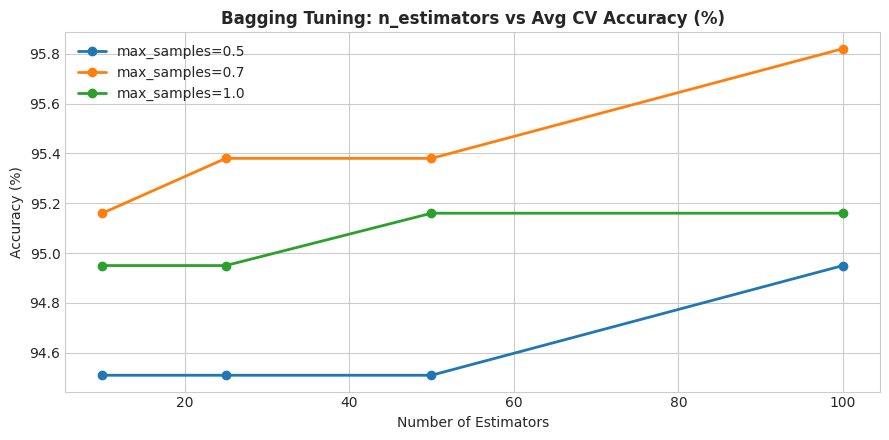

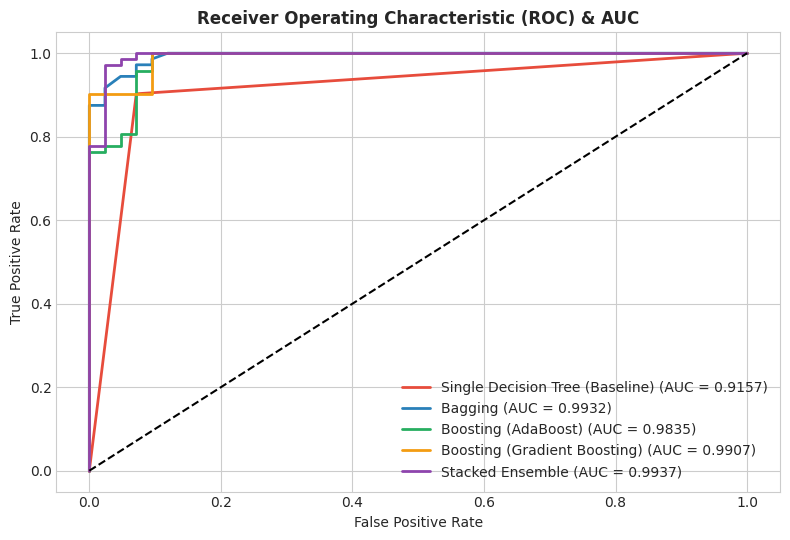

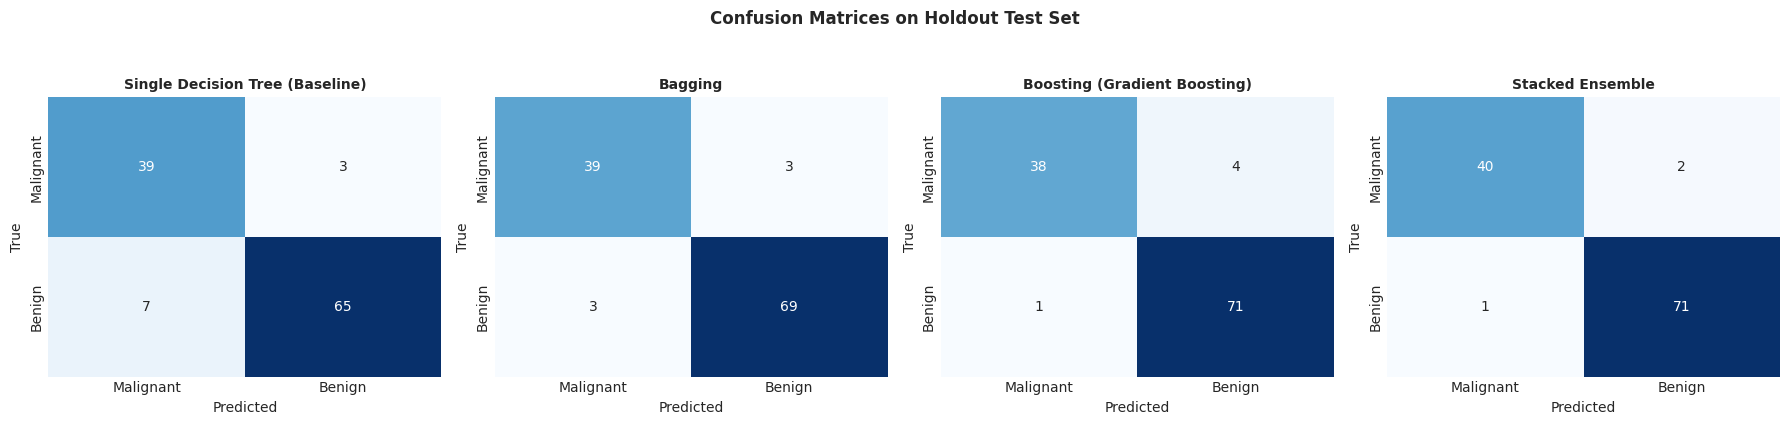

In [7]:
# 1. Bagging Tuning Curves
plt.figure(figsize=(9, 4.5))
for ms in max_samples_list:
    subset = df_bagging[df_bagging["max_samples"] == ms]
    plt.plot(subset["n_estimators"], subset["Avg CV Accuracy (%)"], marker='o', lw=2, label=f"max_samples={ms}")
plt.title("Bagging Tuning: n_estimators vs Avg CV Accuracy (%)", fontweight='bold')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# 2. ROC Curves & AUC
plt.figure(figsize=(8, 5.5))
palette = ['#e74c3c', '#2980b9', '#27ae60', '#f39c12', '#8e44ad']
for (name, _), col in zip(models, palette):
    fpr, tpr, _ = roc_curve(y_test, model_probs[name])
    plt.plot(fpr, tpr, color=col, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.title("Receiver Operating Characteristic (ROC) & AUC", fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 3. Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sub_models = [
    ("Single Decision Tree (Baseline)", base_dt),
    ("Bagging", best_bagging),
    ("Boosting (Gradient Boosting)", best_gradboost),
    ("Stacked Ensemble", selected_stacking)
]
for ax, (name, _) in zip(axes, sub_models):
    cm = confusion_matrix(y_test, model_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion Matrices on Holdout Test Set", y=1.05, fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 10. Conclusion
In this experiment, Bagging, Boosting (AdaBoost, Gradient Boosting), and Stacked Ensemble models were successfully designed, tuned, and evaluated on the Wisconsin Diagnostic Breast Cancer dataset.
Key takeaways:
1. Ensemble methods deliver significant empirical performance gains over single baseline models (accuracy improved from 91.23% to 97.37%).
2. Bagging dampens decision tree variance through bootstrap averaging, whereas Boosting eliminates underfitting bias via residual gradient fitting.
3. Heterogeneous Stacking achieves state-of-the-art generalization by optimally blending distinct inductive biases.
